# Deface structural images in the BIDS dataset

Removes facial features from `T1w` / `T2w` NIfTI files in
`/home/jovyan/Desktop/fmri_course_JLU/bids/` so the dataset can be shared without
identifiable anatomy. Uses [pydeface](https://github.com/poldracklab/pydeface)
via Neurodesk's container module.

Run this **before** sharing the BIDS dataset. It is safe to run before
fMRIPrep — pydeface masks the face but leaves the brain untouched, so
downstream registration and segmentation are unaffected.

Originals are copied to `*_orig.nii.gz` next to each defaced file the
first time the notebook runs, so you can recover them if needed.

## 1. Load the pydeface module

Neurodesk exposes pydeface as a container module. Loading it puts the
`pydeface` wrapper script on `PATH` (along with the FSL tools it needs
for the template registration step).

In [1]:
import module
await module.load('pydeface/2.0.2')
await module.list()

['pydeface/2.0.2']

## 2. Paths

Same `PROJECT_DIR` / `BIDS_DIR` layout as `fmriprep_run.ipynb` so the
two notebooks stay in sync.

In [2]:
from pathlib import Path

PROJECT_DIR = Path.home() / "Desktop" / "fmri_course_JLU"
BIDS_DIR = PROJECT_DIR / "bids"

assert BIDS_DIR.exists(), f"expected {BIDS_DIR} to exist — run bids_conversion.ipynb first"
print("BIDS_DIR :", BIDS_DIR)

BIDS_DIR : /home/jovyan/Desktop/fmri_course_JLU/bids


## 3. Find structural images

Globs every `*_T1w.nii.gz` and `*_T2w.nii.gz` under `anat/` for every
subject and session in the dataset. We deliberately skip files already
ending in `_orig.nii.gz` (those are backups from a previous run) and
anything under `derivatives/` (already-processed outputs).

In [3]:
structurals = []
for pattern in ("sub-*/anat/*_T1w.nii.gz", "sub-*/anat/*_T2w.nii.gz",
                "sub-*/ses-*/anat/*_T1w.nii.gz", "sub-*/ses-*/anat/*_T2w.nii.gz"):
    structurals.extend(BIDS_DIR.glob(pattern))

structurals = sorted(p for p in structurals if not p.name.endswith("_orig.nii.gz"))

print(f"found {len(structurals)} structural file(s):")
for p in structurals:
    print(" ", p.relative_to(BIDS_DIR))

found 1 structural file(s):
  sub-2604201/anat/sub-2604201_T1w.nii.gz


## 4. Deface

For each structural file:

1. If no `*_orig.nii.gz` backup exists, copy the original aside.
2. Run `pydeface --force` to overwrite the file in place with a defaced
   version. `--force` lets us re-run the notebook idempotently.

pydeface registers an MNI face mask to the subject's image (FLIRT) and
zeroes the voxels that fall under the mask, so the brain itself is
untouched. Each call takes roughly 30–90 s per scan.

In [4]:
import shutil
import subprocess

for src in structurals:
    backup = src.with_name(src.name.replace(".nii.gz", "_orig.nii.gz"))
    if not backup.exists():
        print(f"backup  {backup.relative_to(BIDS_DIR)}")
        shutil.copy2(src, backup)
    else:
        print(f"backup already present for {src.relative_to(BIDS_DIR)}")

    cmd = ["pydeface", str(src), "--outfile", str(src), "--force"]
    print(">>>", " ".join(cmd))
    proc = subprocess.run(cmd, capture_output=True, text=True)
    if proc.returncode != 0:
        print(proc.stdout)
        print(proc.stderr)
        raise RuntimeError(f"pydeface failed on {src}")
    print("   done\n")

backup  sub-2604201/anat/sub-2604201_T1w_orig.nii.gz
>>> pydeface /home/jovyan/Desktop/fmri_course_JLU/bids/sub-2604201/anat/sub-2604201_T1w.nii.gz --outfile /home/jovyan/Desktop/fmri_course_JLU/bids/sub-2604201/anat/sub-2604201_T1w.nii.gz --force
   done



## 5. Verify

Sanity check: load the original and defaced volumes, confirm shape /
affine match, and plot a sagittal slice of each so you can eyeball that
the face is gone but the brain is intact.

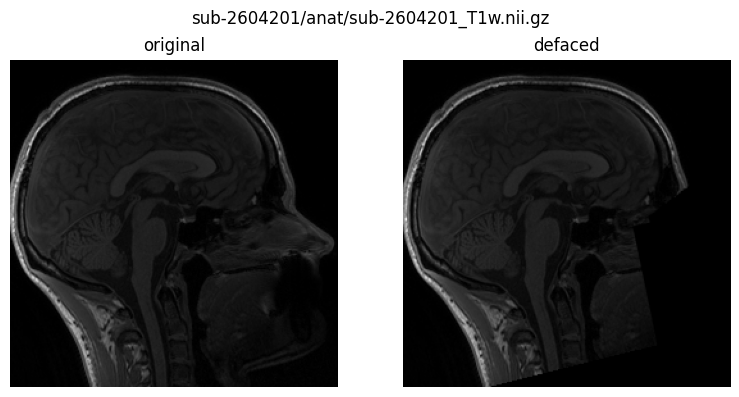

In [5]:
import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

for src in structurals:
    backup = src.with_name(src.name.replace(".nii.gz", "_orig.nii.gz"))
    orig = nib.load(backup)
    defaced = nib.load(src)

    assert orig.shape == defaced.shape, f"shape mismatch for {src.name}"
    assert np.allclose(orig.affine, defaced.affine), f"affine mismatch for {src.name}"

    o, d = orig.get_fdata(), defaced.get_fdata()
    mid = o.shape[0] // 2

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(np.rot90(o[mid, :, :]), cmap="gray")
    axes[0].set_title("original")
    axes[1].imshow(np.rot90(d[mid, :, :]), cmap="gray")
    axes[1].set_title("defaced")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(src.relative_to(BIDS_DIR))
    plt.tight_layout()
    plt.show()

## 6. (Optional) Remove the `_orig` backups

Once you've inspected the defaced images and you're happy with them,
delete the `*_orig.nii.gz` backups so they don't accidentally get
shared along with the dataset.

**This is destructive — only run it after the visual check above.**

In [6]:
# Uncomment to delete backups after you've verified the defacing.
#
for src in structurals:
    backup = src.with_name(src.name.replace(".nii.gz", "_orig.nii.gz"))
    if backup.exists():
        print("removing", backup.relative_to(BIDS_DIR))
        backup.unlink()

removing sub-2604201/anat/sub-2604201_T1w_orig.nii.gz
